# This Notebooke only for training Huggingface WordPiece Tokenizer on Librispeech texts



**For more information on how Tokenizer work you can check the documentaion:** 

[Hugging Face Tokenizers](https://huggingface.co/docs/tokenizers/pipeline)

**For more information on WordPiece Tokenizer**
1) [Hugging Face Tokenizers](https://huggingface.co/course/chapter6/6?fw=pt)

2) [freeCodeCamp](https://www.freecodecamp.org/news/train-algorithms-from-scratch-with-hugging-face/)

3) [How to Build a WordPiece Tokenizer For BERT](https://towardsdatascience.com/how-to-build-a-wordpiece-tokenizer-for-bert-f505d97dddbb)


---
.

.

.


## 1. WordPiece Tokenizer

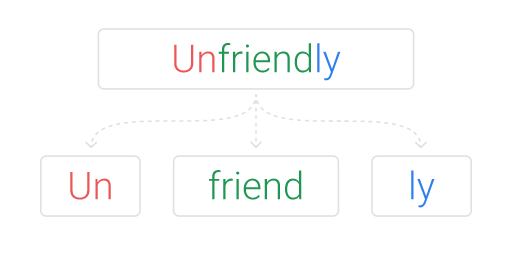


### 2. Pipeline for WordPiece Tokenizer

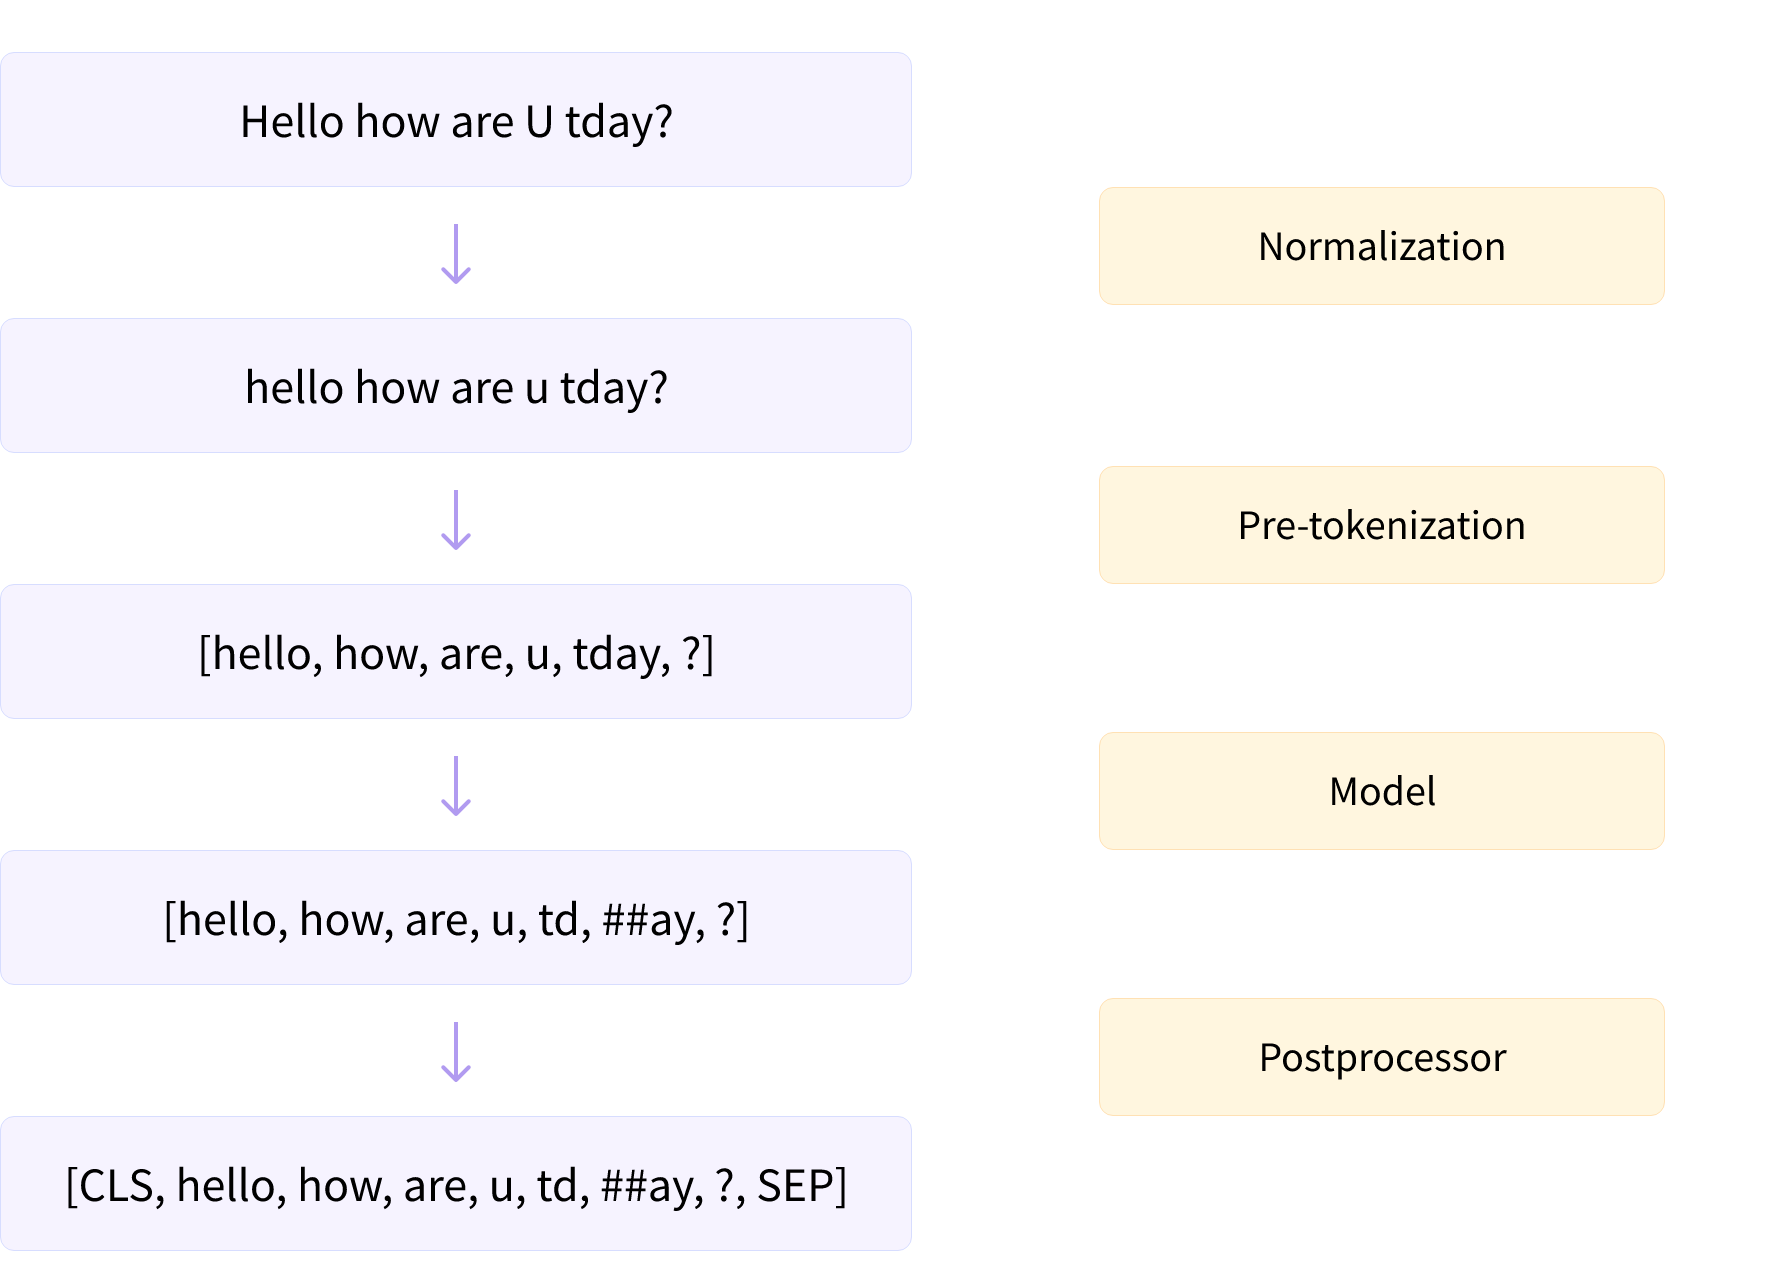


# 1.0 Getting Starting


In [ ]:
# ! pip install tokenizers    # skip if you install it

## 1.1 Import Libraries

In [1]:
import re
from tqdm import tqdm
import unicodedata
from tokenizers import Tokenizer
from tokenizers.models import WordPiece
from tokenizers.pre_tokenizers import Whitespace
from tokenizers import normalizers
from tokenizers.normalizers import NFD, StripAccents
from tokenizers import pre_tokenizers
from tokenizers.pre_tokenizers import Digits
from tokenizers.processors import TemplateProcessing
from tokenizers import decoders
from tokenizers import trainers
import os
from os.path import join

# 2.0 Helper functions

In [2]:
def english_preprocess(s: str):
    '''Remove non english characters and unnecessary spaces.
    @input: string
    @return: cleaned string
    '''
    
    s = re.sub(r"\([\sa-zA-Z]+\)+", " ", s)
    s = re.sub(r"[^\sa-zA-Z0-9?!'.]+", "", s)
    s = re.sub(r'[" "]+', " ", s)
    s = s.rstrip().strip()
    return s

def gen(files: list, preprocess):
    '''Line generator.
    take list of files and iterate line by line on each file.
    @input: files       --> list of file pathes
            preprocess  --> addres of the function that will be applied on each line.
    
    @return: line by line from each file 
    '''
    i = 0
    for ff in tqdm(files):
        with open(ff, 'r', errors='ignore') as f:
            for line in f:
                yield preprocess(line)
#                 print('file:', i, '/', len(files), end='\r')
#                 i += 1
        

In [3]:
t = 'hello, ( how  ) are (you)?'
english_preprocess(t)

'hello are ?'

# 3.0 Training function


In [4]:
def get_tokenizer(files: list, vocab_size: int, save_dir: str, file_name: str, preprocess):
    '''Train and save Whitespace tokenizer.
    @inputs: file        --> list of file pathes.
             vocab_size  --> size of generated dictionary.
             save_dir    --> save dir.
             file_name   --> name of saved tokenizer
             preprocess  --> addres of the function that will be applied on each line.
             
    @return: trained tokenizer    (you can dismiss that)
    '''

    unk_token = "<UNK>"  # token for unknown words
    spl_tokens = ["<UNK>", "<SEP>", "<MASK>", "<CLS>", "<PAD>"]  # special tokens
    tokenizer = Tokenizer(WordPiece(unk_token = unk_token))
    

    normalizer = normalizers.Sequence([NFD(), StripAccents()])
    pre_tokenizer = Whitespace()
    pre_tokenizer = pre_tokenizers.Sequence([Whitespace(), Digits(individual_digits=False)])
    
    tokenizer.normalizer = normalizer
    tokenizer.pre_tokenizer = pre_tokenizer
    tokenizer.post_processor = TemplateProcessing(single="<CLS> $A <SEP>",
                                                  pair="<CLS> $A <SEP> $B:1 <SEP>:1",
                                                  special_tokens=[("<CLS>", 1), ("<SEP>", 2)])

    tokenizer.decoder = decoders.WordPiece()
    trainer = trainers.WordPieceTrainer(vocab_size=vocab_size, special_tokens=spl_tokens)
    try:
        print('Start training')
        tokenizer.train_from_iterator(gen(files, preprocess), trainer)
        print('finish training')
    except KeyboardInterrupt:
        print('trainign stop')
        
    tokenizer.save(f"{save_dir}/{file_name}.json")
    
    return tokenizer.from_file(f"{save_dir}/{file_name}.json")



# 4.0 Start training 

In [5]:
# hyperparameters
save_dir       = r'/kaggle/working/tokens'
data_path      = r'/kaggle/input/librispeech-asr-wav-dataset/meta/books'
tokenizer_name = 'libri_tokenizer'
os.makedirs(save_dir, exist_ok=True)
files = [join(data_path, i) for i in os.listdir('/kaggle/input/librispeech-asr-wav-dataset/meta/books')]


# start training
tokenizer = get_tokenizer(files, 1000, save_dir, tokenizer_name, english_preprocess)

Start training


100%|██████████| 1485/1485 [10:03<00:00,  2.46it/s]





finish training


# 5.0 working with our trained tokenizer and create class to manage its functions

you can take our generated json file and dismiss all previous steps and start work from here.

## 5.1 import Import Libraries

In [6]:
from tokenizers import Tokenizer
from tokenizers import decoders

## 5.2 define our class

In [7]:
class TokenHandler:
    def __init__(self, json_path: str):
        self.tok = Tokenizer.from_file(json_path)
        self.tok.enable_padding(pad_id=self.get_id("<PAD>"), pad_token="<PAD>")
        
    def enocde_line(self, text: str):
        '''@input: text --> single string.
        @return:  ids, tokens
        '''
        out = self.tok.encode(text)
        return out.ids, out.tokens
    
    def get_id(self, token: int):
        '''@input: token --> single word 
        @return: id --> int
        '''
        return self.tok.token_to_id(token)
    
    def encode_batch(self, data: list):
        '''@input: data --> list of strings.
        @return:  ids, tokens
        '''
        output = self.tok.encode_batch(data)
        return [o.ids for o in output], [o.tokens for o in output]
    
    def decode_line(self, ids: list):
        '''@input: ids --> list of int
        @return: text --> single string.
        '''
        return self.tok.decode(ids)
    
    def decode_batch(self, ids: list):
        return self.tok.decode_batch(ids)

## 5.3 Testing it working

In [8]:
path = r"/kaggle/working/tokens/libri_tokenizer.json"
en_token = TokenHandler(path)
text = "hello , how're you? I hope you are fine."
ids = en_token.enocde_line(text)
print(ids)
# tok = en_token.decode_batch(ids)
# print(tok)

([1, 968, 88, 89, 0, 491, 6, 198, 190, 18, 27, 52, 799, 190, 296, 50, 392, 7, 2], ['<CLS>', 'hel', '##l', '##o', '<UNK>', 'how', "'", 're', 'you', '?', 'I', 'h', '##ope', 'you', 'are', 'f', '##ine', '.', '<SEP>'])


In [9]:
os.listdir('/kaggle/working/tokens')

['libri_tokenizer.json']